In [1]:
# ============================================================
# 1. IMPORT LIBRARIES & SETUP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

os.makedirs("EDA_Plots", exist_ok=True)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("olist_merged_dataset.csv")

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)

print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

DATASET LOADED
Shape: (113425, 18)

First 5 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [3]:
# ============================================================
# 3. DATA PREPARATION
# ============================================================

required_columns = [
    "customer_unique_id",
    "order_id",
    "price",
    "freight_value"
]

print("Required columns:")
print(required_columns)

print("\nMissing values:")
print(df[required_columns].isnull().sum())

df = df.dropna(subset=["customer_unique_id"])

df = df.dropna(
    subset=["order_id", "price", "freight_value"]
)

df = df[
    (df["price"] >= 0) &
    (df["freight_value"] >= 0)
]

print("\nShape after data preparation:")
print(df.shape)

Required columns:
['customer_unique_id', 'order_id', 'price', 'freight_value']

Missing values:
customer_unique_id      0
order_id                0
price                 775
freight_value         775
dtype: int64

Shape after data preparation:
(112650, 18)


In [4]:
# ============================================================
# 4. CUSTOMER-LEVEL DATA AGGREGATION
# ============================================================

customer_data = df.groupby(
    "customer_unique_id"
).agg(
    Number_of_Orders=("order_id", "nunique"),
    Total_Spending=("price", "sum"),
    Average_Order_Value=("price", "mean"),
    Total_Freight=("freight_value", "sum")
).reset_index()

print("Customer-level dataset:")
display(customer_data.head())

print("\nNumber of customers:", len(customer_data))

Customer-level dataset:


,customer_unique_id,Number_of_Orders,Total_Spending,Average_Order_Value,Total_Freight
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,129.90,12.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,18.90,8.29
2,0000f46a3911fa3c0805444483337064,1,69.00,69.00,17.22
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,25.99,17.63
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,180.00,16.89



Number of customers: 95420


In [5]:
# ============================================================
# 5. FEATURE SELECTION
# ============================================================

features = [
    "Number_of_Orders",
    "Total_Spending",
    "Average_Order_Value",
    "Total_Freight"
]

X = customer_data[features].copy()

print("Features selected for clustering:")

for feature in features:
    print("-", feature)

print("\nFeature data:")
display(X.head())

Features selected for clustering:
- Number_of_Orders
- Total_Spending
- Average_Order_Value
- Total_Freight

Feature data:


,Number_of_Orders,Total_Spending,Average_Order_Value,Total_Freight
0,1,129.90,129.90,12.00
1,1,18.90,18.90,8.29
2,1,69.00,69.00,17.22
3,1,25.99,25.99,17.63
4,1,180.00,180.00,16.89


In [6]:
# ============================================================
# 6. OUTLIER TREATMENT
# ============================================================

for col in features:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (X[col] < lower_bound) |
        (X[col] > upper_bound)
    ).sum()

    print(f"{col}: {outliers} outliers")

    X[col] = X[col].clip(lower_bound, upper_bound)

print("\nIQR clipping applied successfully.")

Number_of_Orders: 2913 outliers
Total_Spending: 8012 outliers
Average_Order_Value: 7416 outliers
Total_Freight: 9216 outliers

IQR clipping applied successfully.


In [7]:
# ============================================================
# 7. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("StandardScaler applied.")
print("Scaled feature shape:", X_scaled.shape)

print("\nFirst 5 scaled rows:")
print(X_scaled[:5])

StandardScaler applied.
Scaled feature shape: (95420, 4)

First 5 scaled rows:
[[ 0.          0.16786795  0.34790698 -0.8445342 ]
 [ 0.         -1.08220881 -1.06805482 -1.2036003 ]
 [ 0.         -0.51798498 -0.42895855 -0.33932528]
 [ 0.         -1.00236157 -0.97761186 -0.29964412]
 [ 0.          0.73209179  0.98700325 -0.37126378]]


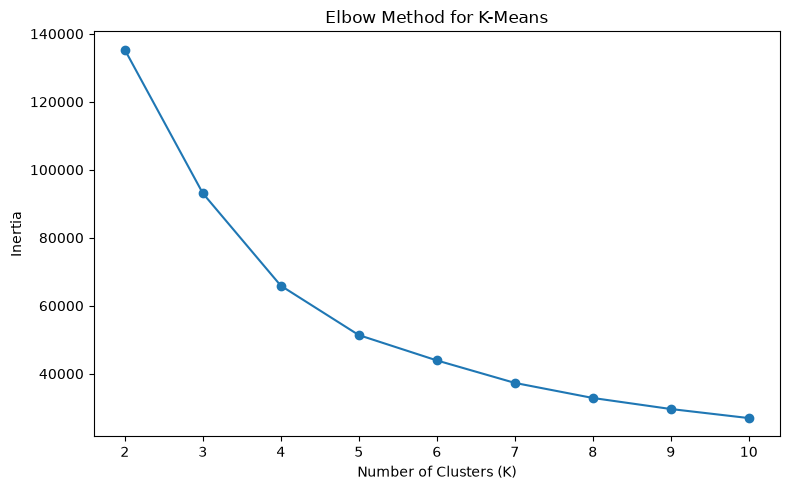

In [8]:
# ============================================================
# 8. ELBOW METHOD
# ============================================================

inertia = []
K_values = range(2, 11)

for k in K_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_values, inertia, marker="o")

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(K_values))

plt.tight_layout()
plt.savefig("EDA_Plots/clustering_elbow.png", dpi=150)
plt.show()

In [9]:
# ============================================================
# 9. SILHOUETTE SCORE
# ============================================================

silhouette_scores = {}

for k in K_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores[k] = score

    print(
        f"K = {k} | "
        f"Silhouette Score = {score:.4f}"
    )

K = 2 | Silhouette Score = 0.5224
K = 3 | Silhouette Score = 0.4874


MemoryError: Unable to allocate 1.00 GiB for an array with shape (1406, 95420) and data type float64

In [ ]:
# ============================================================
# 10. BEST NUMBER OF CLUSTERS
# ============================================================

best_k = max(
    silhouette_scores,
    key=silhouette_scores.get
)

print("Best K:", best_k)

print(
    "Best Silhouette Score:",
    round(silhouette_scores[best_k], 4)
)

In [ ]:
# ============================================================
# 11. K-MEANS CLUSTERING
# ============================================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

customer_data["Cluster"] = cluster_labels

print("K-Means clustering completed!")

print("\nCluster labels:")
display(
    customer_data[
        ["customer_unique_id", "Cluster"]
    ].head(10)
)

In [ ]:
# ============================================================
# 12. CLUSTER DISTRIBUTION
# ============================================================

cluster_counts = (
    customer_data["Cluster"]
    .value_counts()
    .sort_index()
)

print("Number of customers in each cluster:")
print(cluster_counts)

In [ ]:
# ============================================================
# 13. CLUSTER PROFILING
# ============================================================

cluster_profile = customer_data.groupby(
    "Cluster"
).agg(
    Customers=("customer_unique_id", "count"),
    Average_Orders=("Number_of_Orders", "mean"),
    Average_Spending=("Total_Spending", "mean"),
    Average_Order_Value=("Average_Order_Value", "mean"),
    Average_Freight=("Total_Freight", "mean")
)

print("Cluster Profile:")
display(cluster_profile)

In [ ]:
# ============================================================
# 14. AVERAGE SPENDING BY CLUSTER
# ============================================================

plt.figure(figsize=(9, 6))

sns.barplot(
    data=customer_data,
    x="Cluster",
    y="Total_Spending",
    estimator="mean"
)

plt.title("Average Spending by Customer Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Average Total Spending")

plt.tight_layout()
plt.savefig(
    "EDA_Plots/average_spending_by_cluster.png",
    dpi=150
)
plt.show()

In [ ]:
# ============================================================
# 15. CLUSTER SIZE VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=customer_data,
    x="Cluster"
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("EDA_Plots/cluster_size.png", dpi=150)
plt.show()

In [ ]:
# ============================================================
# 16. CUSTOMER SEGMENTATION VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=customer_data,
    x="Total_Spending",
    y="Number_of_Orders",
    hue="Cluster",
    palette="Set2",
    alpha=0.5,
    s=15,
    legend="auto"
)

plt.title("Customer Segmentation")
plt.xlabel("Total Spending")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.savefig(
    "EDA_Plots/customer_segmentation.png",
    dpi=150
)
plt.show()

plt.close()


In [ ]:
# ============================================================
# 17. FINAL CLUSTERING EVALUATION
# ============================================================

final_score = silhouette_score(
    X_scaled,
    customer_data["Cluster"]
)

print("=" * 70)
print("FINAL CLUSTERING EVALUATION")
print("=" * 70)

print("Best Number of Clusters:", best_k)
print(
    "Final Silhouette Score:",
    round(final_score, 4)
)

In [ ]:
# ============================================================
# 18. SAVE RESULTS
# ============================================================

customer_data.to_csv(
    "customer_segments.csv",
    index=False
)

cluster_profile.to_csv(
    "cluster_profile.csv"
)

print("Results saved successfully!")

print("\nFiles created:")
print("1. customer_segments.csv")
print("2. cluster_profile.csv")

In [ ]:
# ============================================================
# 19. FINAL WORKFLOW SUMMARY
# ============================================================

print("=" * 70)
print("CLUSTERING WORKFLOW COMPLETED")
print("=" * 70)

print("""
1. Dataset loaded
2. Data prepared
3. Customer-level data created
4. Features selected
5. Outliers treated using IQR clipping
6. Features scaled using StandardScaler
7. Elbow Method applied
8. Silhouette Score calculated
9. Best number of clusters selected
10. K-Means clustering applied
11. Customers assigned to clusters
12. Cluster profiles created
13. Clusters visualized
14. Clustering evaluated
15. Results saved

Machine Learning Type:
UNSUPERVISED LEARNING

Algorithm:
K-MEANS CLUSTERING

Objective:
CUSTOMER SEGMENTATION
""")

print("=" * 70)
print("CLUSTERING COMPLETED SUCCESSFULLY!")
print("=" * 70)

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

customer_data["Cluster"] = kmeans.fit_predict(
    customer_data[["Total_Spending", "Number_of_Orders"]]
)

print(customer_data["Cluster"].value_counts())

Cluster
0    85884
2     8654
1      882
Name: count, dtype: int64


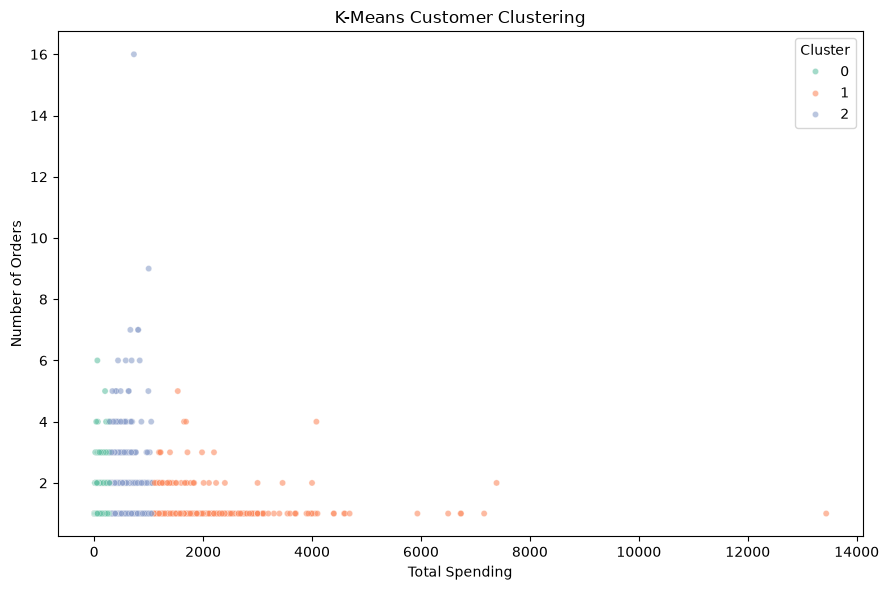

In [14]:
# K-Means Clustering Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=customer_data,
    x="Total_Spending",
    y="Number_of_Orders",
    hue="Cluster",
    palette="Set2",
    s=20,
    alpha=0.6
)

plt.title("K-Means Customer Clustering")
plt.xlabel("Total Spending")
plt.ylabel("Number of Orders")
plt.legend(title="Cluster")

plt.tight_layout()
plt.savefig("EDA_Plots/kmeans_clustering.png", dpi=150)
plt.show()
plt.close()

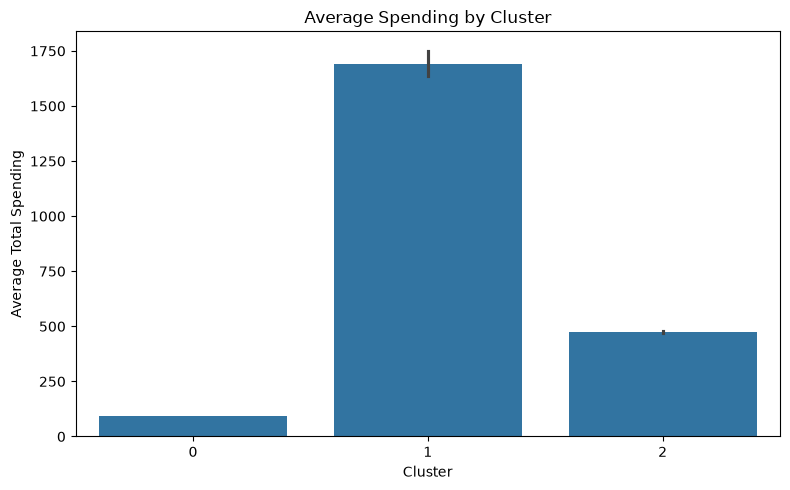

In [15]:
# Average Spending by Cluster

plt.figure(figsize=(8, 5))

sns.barplot(
    data=customer_data,
    x="Cluster",
    y="Total_Spending",
    estimator="mean"
)

plt.title("Average Spending by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Total Spending")

plt.tight_layout()
plt.savefig("EDA_Plots/average_spending_by_cluster.png", dpi=150)
plt.show()
plt.close()

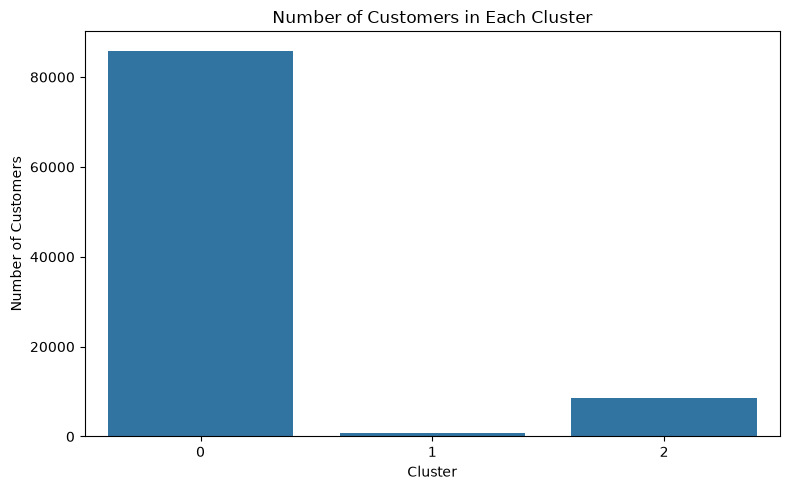

In [16]:
# Cluster Size

plt.figure(figsize=(8, 5))

sns.countplot(
    data=customer_data,
    x="Cluster"
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("EDA_Plots/cluster_size.png", dpi=150)
plt.show()
plt.close()